## code to load in all datasets, create unique id's for them, then combine into single dataframe

List of datasets:
- SeaBASS (by region)
    - SB_chl_na.xlsx
- CalCOFI
    - calcofi_chl_qc.xlsx
- Gloria
    - NONE
- HOTS
    - hots_chl_qc.xlsx
- IOOS
    - ioos_chl_qc.xlsx(note:this is reduced to single day ones)
- WOD (1, 2, Ecomon)
    - wod_chl_na.xlsx
- BCO-DMO
    - bco_dmo_chl_qc.xlsx
- AquaMatch
    - aquamatch_chl_na.xlsx
- GLOBEC
    - globec_chl_qc.xlsx

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
#ALL dataframes should have experiment, data_type (if possible), affiliations, investigators, contact, url
#IF the dataset does not have experiemnent, remove?? only once i concat

# Chlorophyll ID column and final concatination

In [2]:
CalCOFI = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\calcofi_chl_qc.xlsx')
CalCOFI = CalCOFI.rename(columns={'identifier_product_doi':'DOI_url'})
CalCOFI['experiment']='CalCOFI'
CalCOFI['affiliations']='NOAA Fisheries, Scripps, CDFW'
CalCOFI['data_type']='bottle'

In [3]:
gloria_chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_chl_na.xlsx')
gloria_chl['datetime'] = pd.to_datetime(gloria_chl['datetime'])

In [4]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url','decision':'data_type_flag'})

#Calcofi has some unique data on seabass, so only the ones that overlap with calcofi, not all seabass.experiment = CalCOFI
sb_calc = CalCOFI[['datetime', 'lat', 'lon','depth']] #reduce to datetime, lat, lon, and depth for  matching
seabass['depth'] =seabass['depth'].astype('int64') #to match datatype of calcofi
#merge the two dataframes on similar columns
seabass = seabass.merge(sb_calc[['datetime', 'lat', 'lon','depth']], on=['datetime', 'lat', 'lon','depth'], how='left', indicator=True) #all calcofi data with seabass indicator
seabass =  seabass[seabass['_merge'] != 'both'] #remove rows where _merge has both
seabass=seabass[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag']]
seabass['source']='SeaBASS'

In [5]:
#now that calcofi data has been removed, remove any repeated gloria data
gloria_sb = gloria_chl[gloria_chl['DOI_url'] !='https://doi.pangaea.de/10.1594/PANGAEA.948492'] #remove any data without seabass doi
gloria_sb=gloria_sb.rename(columns={"DOI_url": "doi_url"}) #temporary doi to match seabass temporary doi 
gloria_sb=gloria_sb[['datetime', 'depth','doi_url','lat', 'lon','chl']]

seabass['datetime'] = pd.to_datetime(seabass['datetime'])
seabass_test=seabass.copy()
seabass_test['doi_url'] = seabass_test['DOI_url'].str.lower() #all lowercase to match with gloria naming convention 

test2 = pd.merge(gloria_sb, seabass_test, on=['datetime', 'doi_url','lat', 'lon','chl'], how='right',indicator=True).reset_index(drop=True)
seabass1 =  test2[test2['_merge'] != 'both'] #remove rows where _merge has both
seabass1 = seabass1[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth_y', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'contact',
      'source', 'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag']]
seabass = seabass1.rename(columns={'depth_y':'depth'})

In [7]:
#add 2025 data 
seabass2 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_2025.xlsx')
seabass2 = seabass2.rename(columns={'decision':'data_type_flag'})
seabass2=seabass2[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'cruise', 
                   'HPLC', 'triplicate', 'data_type_flag']]
seabass2['source']='SeaBASS'

In [8]:
HOTS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\hots_chl_qc.xlsx')
HOTS = HOTS.rename(columns={'url':'DOI_url'})
HOTS['data_type']='bottle'

In [18]:
IOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_chl_qc2.xlsx')
IOOS = IOOS.rename(columns={'url':'DOI_url','Institution':'affiliations','date':'datetime','decision':'data_type_flag'})
IOOS=IOOS[['datetime', 'lat', 'lon', 'chl', 'depth', 'source', 'affiliations', 'DOI_url', 'experiment', 'HPLC', 'triplicate','data_type_flag']] 
IOOS = IOOS[IOOS['datetime'] <= '2026-01-01'] #only keep 2025 data
#remove 'Dataset ID' since repeat of experiment 

In [10]:
bco = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_chl_qc.xlsx')
bco = bco.rename(columns={'url':'DOI_url'})

In [23]:
#wod doesn't always have experiment, but always has accession number i.e. NODC accession number so use that instead 
wod = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\wod_chl_na.xlsx')
wod['source'] = 'WOD'
wod['DOI_url'] = 'https://www.ncei.noaa.gov/access/world-ocean-database-select/dbsearch.html'
wod=wod[['datetime', 'lat', 'lon', 'chl', 'depth', 'cruise','affiliations', 'source','investigators', 'HPLC', 'triplicate','decision', 'accession number']]
wod = wod.rename(columns={'accession number':'experiment','decision':'data_type_flag'})

In [12]:
aqua = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\aquamatch_chl_na.xlsx')
aqua = aqua.rename(columns={'url':'DOI_url'})
aqua['experiment']='AquaMatch'

In [13]:
globec = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\globec_chl_qc.xlsx')
globec = globec.rename(columns={'url':'DOI_url'})

In [24]:
dfs=[seabass,seabass2,aqua,bco,CalCOFI,globec,HOTS,IOOS,wod,gloria_chl]
all_chl = pd.concat(dfs).reset_index(drop=True)
all_chl = all_chl.dropna(subset=['chl', 'chl_a'], how='all')
all_chl = all_chl.dropna(subset=['datetime'], how='all') #if no datetime, remove

#so usually, HPLC chl is in the chl_a column. HOwever, sometimes a project lables hplc chlorophyll as chl (NOT chl_a). 
#so, to keep it consistant, what i need to do is 1. IF HPLC is flagged as good (0), 2. if chl_a is empty, THEN populate with the value in chl.
#that way, we retain what the original data source says, but it makes the HPLC data more consistant. Sometimes chl and chl_a are both recorded also
all_chl.loc[(all_chl['HPLC']== 0) & (all_chl['chl_a'].isnull()), 'chl_a'] = all_chl['chl']

In [25]:
#remove all negative values from column
condition_A = (all_chl['chl'] >= 0) | (all_chl['chl'].isnull())
condition_B = (all_chl['chl_a'] >= 0) | (all_chl['chl_a'].isnull())
all_chl = all_chl[condition_A & condition_B]

In [39]:
#first, create a temporary column that has the xperiment names but without special charecters (_,-,',(,[)
all_chl['temp_exp'] = all_chl['experiment'].str.replace('_', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('-', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(' ', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('(', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(')', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('[', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(']', '', regex=False)

In [40]:
all_chl['ID_code'] = all_chl['source'].astype(str) + '_' + all_chl['temp_exp'].astype(str) + '_' + all_chl['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + all_chl['lat'].astype(str) + '_' + all_chl['lon'].astype(str) +'_' + all_chl['depth'].astype(str)+'m'
#add sequential sample number to repeated id tags
all_chl['ID_code'] = all_chl['ID_code'] + '_' + all_chl.groupby('ID_code').cumcount().astype(str)

In [26]:
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(all_chl, geometry=gpd.points_from_xy(all_chl.lon, all_chl.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
all_chl = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
all_chl = all_chl.drop(columns=columns_to_drop)
all_chl= all_chl.reset_index(drop=True)

In [45]:
all_chl=all_chl[['ID_code','datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag', 'source', 'cast']]

In [46]:
all_chl.to_excel('all_chl.xlsx', index = False)


In [28]:
all_chl.source.value_counts()

source
SeaBASS      248214
IOOS         147213
CalCOFI       88942
WOD           55014
AquaMatch     49944
BCO-DMO       17025
HOTS          10058
GLORIA          787
Name: count, dtype: int64

### chlorophyll plots and visualization

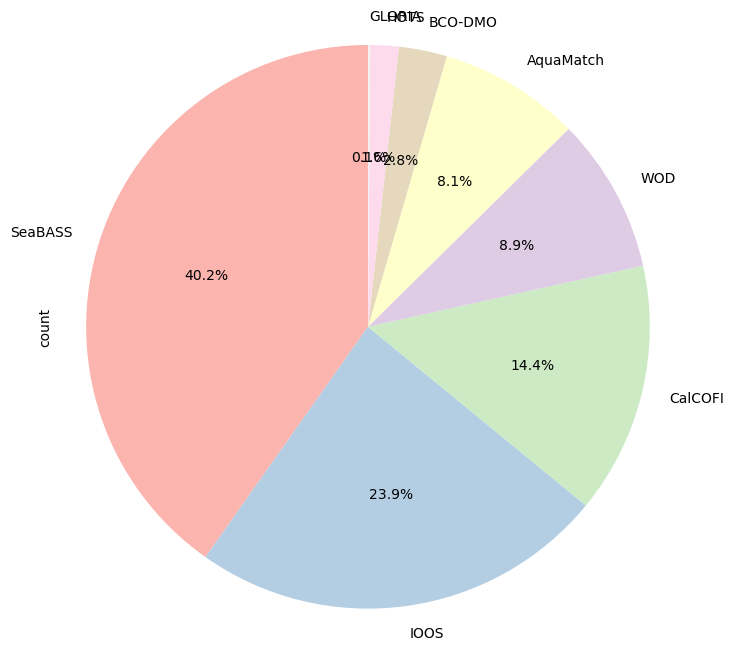

In [29]:
category_counts = all_chl['source'].value_counts() 
plt.figure(figsize=(8, 8)) # Optional: set the figure size
category_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.axis('equal') 
plt.show()

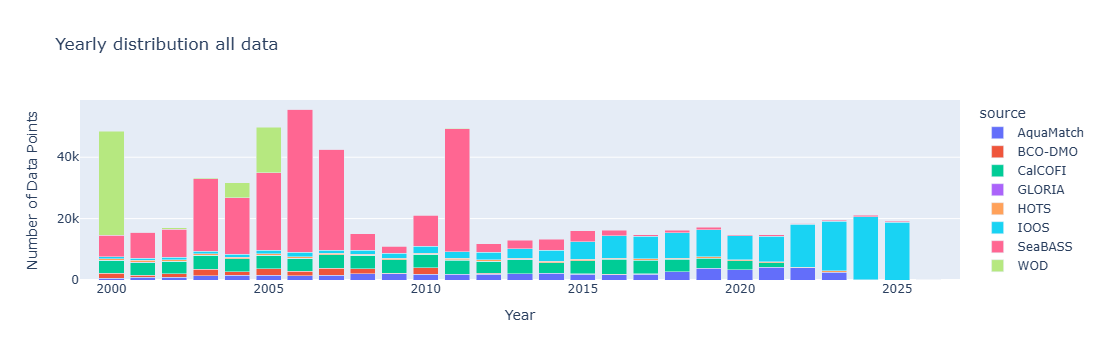

In [30]:
year_test=all_chl.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


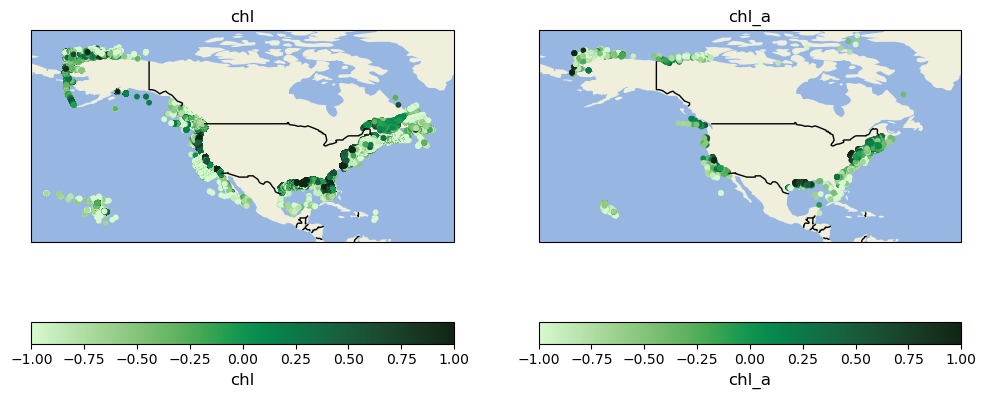

In [31]:
year_test['log_chl']=np.log10(year_test['chl'])
year_test['log_chl_a']=np.log10(year_test['chl_a'])

fig=plt.figure(figsize=(12, 7))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.BORDERS)
im=axs1.scatter(year_test.lon,year_test.lat,c=year_test.log_chl,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs1.set_title('chl')
axs1.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
cb=fig.colorbar(im,ax=axs1,orientation='horizontal')
cb.set_label('chl',fontsize=12)

axs2=fig.add_subplot(1,2,2,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.BORDERS)
im=axs2.scatter(year_test.lon,year_test.lat,c=year_test.log_chl_a,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs2.set_title('chl_a')
cb=fig.colorbar(im,ax=axs2,orientation='horizontal')
cb.set_label('chl_a',fontsize=12)
axs2.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
#,cbar_kwargs={'ticks': [ -1, -0.5,0, 0.5, 1],'format': mticker.FixedFormatter([ 0.1, 0.3, 1, 3,10])}
#im=west_coastchl.plot(ax=axes[1],cmap='viridis',vmin=-1, vmax=1,cbar_kwargs={'ticks': [ -1, -0.5,0, 0.5, 1],'format': mticker.FixedFormatter([ 0.1, 0.3, 1, 3,10])})


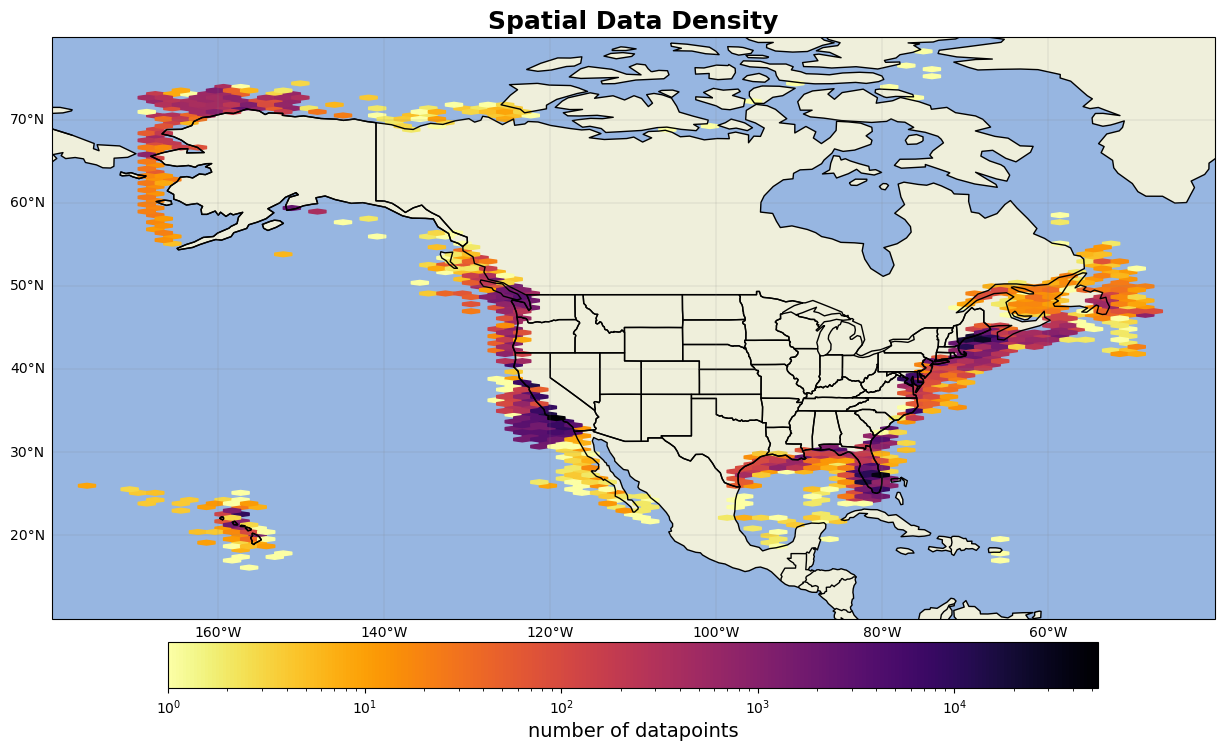

In [51]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=160, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='horizontal', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# RRS

In [2]:
gloria = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_rrs_na.xlsx')
gloria['datetime'] = pd.to_datetime(gloria['datetime'])
gloria['source']='GLORIA'
gloria = gloria[gloria['datetime'] >= '2000-01-01'] #only want data from 2000 on for this algorithm 

In [4]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_rrs_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url'})
seabass=seabass[['datetime', 'lon', 'lat', 'DOI_url', 'affiliations', 'investigators', 'contact', 'experiment', 'cruise',
       'station', 'rrs', 'wavelength', 'depth']]
seabass['source']='SeaBASS'
seabass['datetime'] = pd.to_datetime(seabass['datetime'])


In [7]:
#remove GLORIA data from Seabass 
gloria_sb = gloria[gloria['DOI_url'] !='https://doi.pangaea.de/10.1594/PANGAEA.948492'] #only gather data that has seabass doi
gloria_sb=gloria_sb.rename(columns={"DOI_url": "doi_url"})
gloria_sb=gloria_sb[['datetime', 'doi_url','lat', 'lon','wavelength','rrs']]

seabass_test=seabass.copy()
seabass_test['doi_url'] = seabass_test['DOI_url'].str.lower()

test2 = pd.merge(gloria_sb, seabass_test, on=['datetime', 'doi_url','lat', 'lon','wavelength','rrs'], how='right',indicator=True).reset_index(drop=True)
#seabass data has some wavelengths that gloria does not i.e., 10.5067/seabass/2009oct_chesapeake/data001 has wavelengths above 800 on seabass not on gloria
seabass =  test2[test2['_merge'] != 'both'] #remove rows where _merge has both
seabass=seabass[['datetime', 'lat', 'lon', 'wavelength', 'rrs','source', 'DOI_url', 'affiliations', 'investigators', 'contact', 'experiment', 
                 'cruise','station', 'depth']]

In [11]:
dfs=[seabass,gloria]
all_rrs = pd.concat(dfs).reset_index(drop=True)

In [12]:
all_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'rrs', 'wavelength',  'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 
            'cruise', 'station']
all_rrs = all_rrs.drop_duplicates(subset=all_vars, keep='first')
all_rrs['datetime'] = pd.to_datetime(all_rrs['datetime'])

In [84]:
#so these id tags will be different,, since there can be multiple rows with identical datetime, lon, lat, and depth but unique wavelength
#what i should do i think it first turn the dataframe into rrs_### and create id tags based on that and see what the value_counts is 

In [13]:
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 'cruise', 'station']
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df[id_vars] = df[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df['temp_counter'] = df.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

test = long_to_wide(all_rrs)

In [14]:
test['temp_exp'] = test['experiment'].str.replace('_', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('-', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(' ', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('(', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(')', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('[', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(']', '', regex=False)

test['ID_code'] = (test['source'].astype(str) + '_' + test['temp_exp'].astype(str) + '_' + test['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + 
    test['lat'].astype(str) + '_' + test['lon'].astype(str) + '_' + test['depth'].astype(str) + 'm')
test['ID_code'] = test['ID_code'] + '_' + test.groupby('ID_code').cumcount().astype(str)

In [ ]:
#sometimes there are duplicates/ repeated data that have different rrs values. so add an id tag to THESE and then 
#turn back into long format df, that way these 3 ids will repeat for 9 rows, but they'll all relate to the same datetime lat lon ect without a unique code
#per wavelength value. 
#test2=test[(test['experiment']=='Bold_EPAHypoxia') & (test.lat ==29.532833)]
#test2.to_excel('test2.xlsx', index = False)

In [15]:
#turn back into rrs column adn wavelength column
rrs_cols = [col for col in test.columns if col.startswith('rrs_')]
id_vars_melt = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 'cruise', 'station', 'ID_code']

df_long = test.melt(id_vars=id_vars_melt, value_vars=rrs_cols,var_name='raw_wavelength',value_name='rrs')
df_long['raw_wavelength'] = df_long['raw_wavelength'].str.replace('rrs_', '')
df_long['wavelength'] = pd.to_numeric(df_long['raw_wavelength'])
df_long = df_long.drop(columns=['raw_wavelength'])
df_long = df_long.dropna(subset=['rrs'])
df_long[id_vars_melt] = df_long[id_vars_melt].replace('MISSING_DATA', np.nan)
df_long=df_long.reset_index(drop=True)

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_49212\1789082941.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long[id_vars_melt] = df_long[id_vars_melt].replace('MISSING_DATA', np.nan)


In [16]:
print(len(df_long))
print(len(all_rrs))

1030586
1030586


In [12]:
#a=df_long.ID_code
#a.to_csv('rrs_ids.txt', index=False, header=False, sep='\n')

In [19]:
df_long.to_excel('all_rrs.xlsx', index = False)


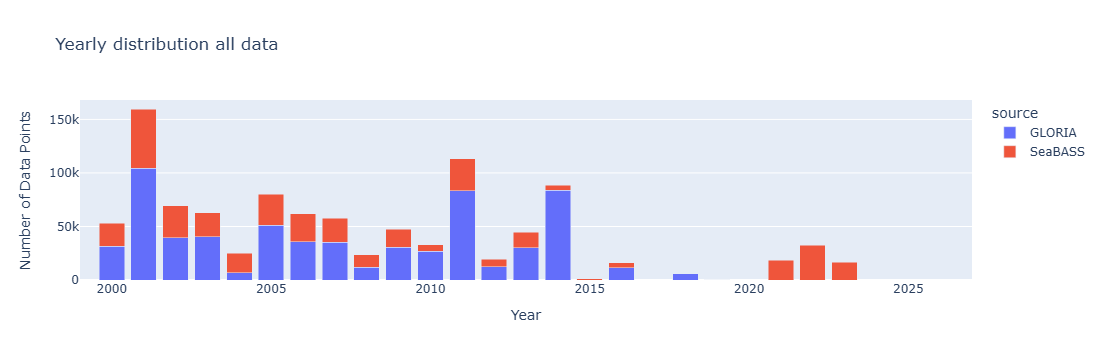

In [17]:
year_test=df_long.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

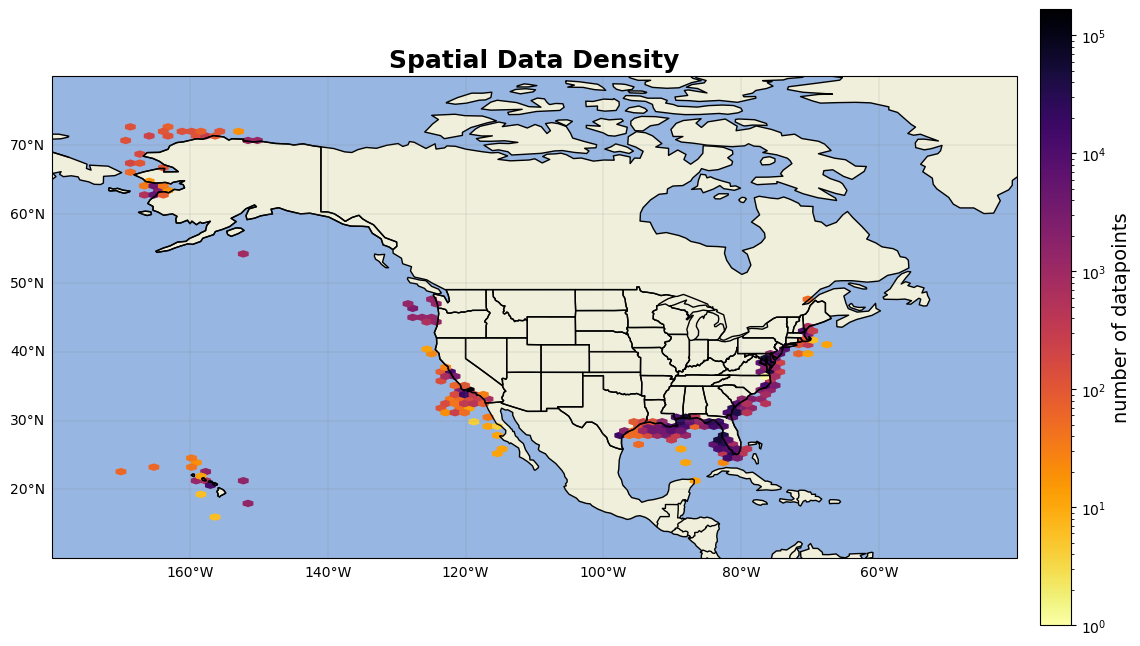

In [18]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(df_long.lon, df_long.lat, gridsize=75, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# CDOM

In [13]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_cdom_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url'})
seabass=seabass[['datetime', 'lon', 'lat', 'DOI_url', 'affiliations','investigators', 'experiment', 'cruise', 'station', 'depth','cdom']]
seabass['source']='SeaBASS'

In [14]:
ioos = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_cdom_na.xlsx')
ioos = ioos.rename(columns={'url':'DOI_url','Institution':'affiliations','date':'datetime','Dataset ID':'station'})
ioos=ioos[['datetime', 'lat', 'lon',  'cdom', 'depth', 'source', 'affiliations', 'DOI_url', 'experiment','station']]

In [15]:
bcodmo = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_cdom_qc.xlsx')
bcodmo = bcodmo.rename(columns={'url':'DOI_url'})
bcodmo=bcodmo[['datetime', 'lat', 'lon', 'depth', 'cruise', 'cdom', 'experiment', 'source', 'investigators', 'affiliations', 'DOI_url',
       'station']]

In [16]:
dfs=[seabass,ioos,bcodmo]
all_cdom = pd.concat(dfs).reset_index(drop=True)
all_cdom = all_cdom.dropna(subset=['cdom'])
all_cdom = all_cdom.drop_duplicates()

In [17]:
#first, create a temporary column that has the xperiment names but without special charecters (_,-,',(,[)
all_cdom['temp_exp'] = all_cdom['experiment'].str.replace('_', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('-', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(' ', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('(', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(')', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('[', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(']', '', regex=False)

In [18]:
all_cdom['ID_code'] = all_cdom['source'].astype(str) + '_' + all_cdom['temp_exp'].astype(str) + '_' + all_cdom['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + all_cdom['lat'].astype(str) + '_' + all_cdom['lon'].astype(str) +'_' + all_cdom['depth'].astype(str)+'m'
#add sequential sample number to repeated id tags
all_cdom['ID_code'] = all_cdom['ID_code'] + '_' + all_cdom.groupby('ID_code').cumcount().astype(str)

In [19]:
all_cdom=all_cdom[['datetime','lon','lat','depth','cdom','DOI_url','affiliations','investigators','experiment', 'cruise', 'station', 'source','ID_code']]

In [20]:
all_cdom=all_cdom[all_cdom['cdom']>=0]

In [21]:
all_cdom.to_excel('all_cdom.xlsx', index = False)


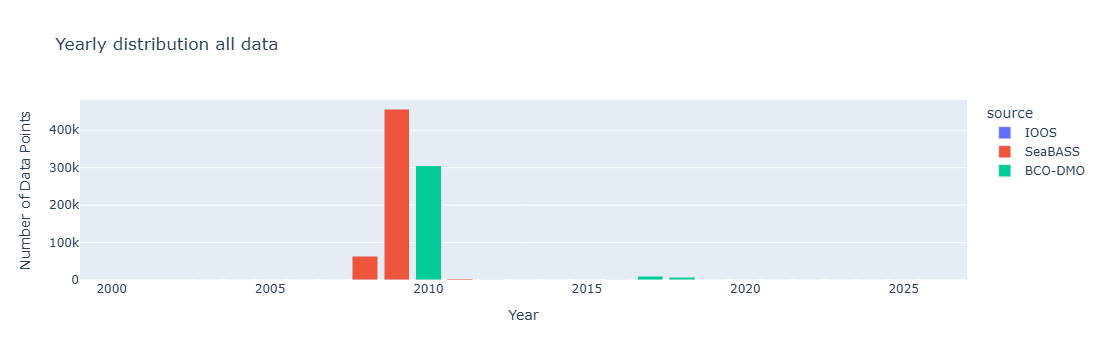

In [22]:
year_test=all_cdom.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

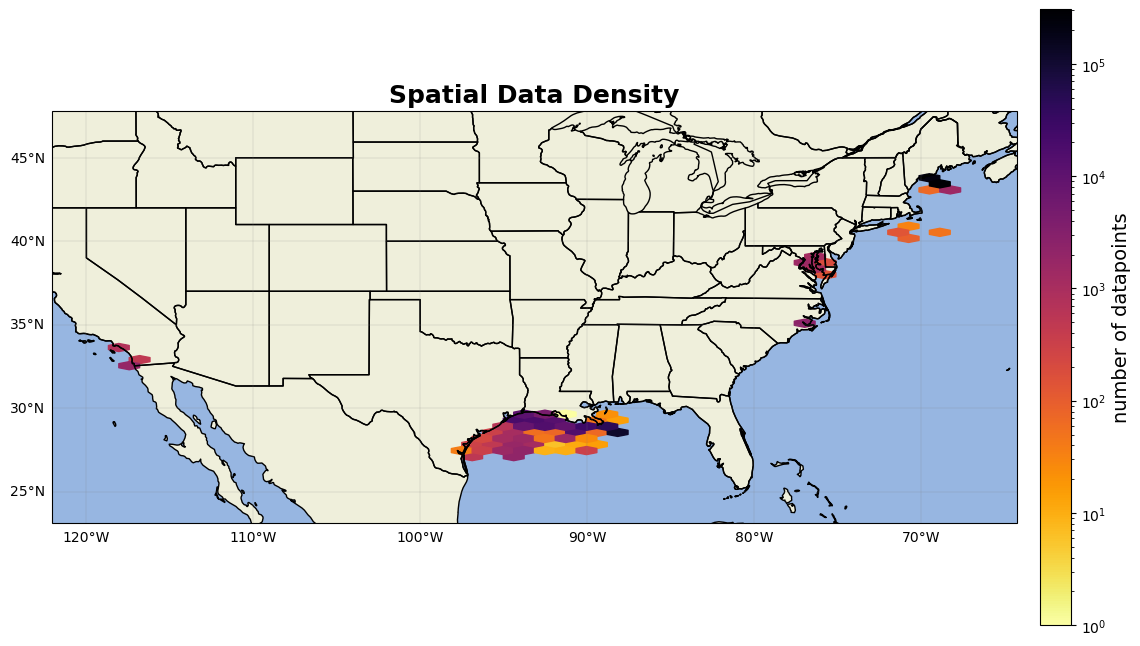

In [23]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(all_cdom.lon, all_cdom.lat, gridsize=40, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(all_cdom.lon)-4,max(all_cdom.lon)+4)
ax.set_ylim(min(all_cdom.lat)-4,max(all_cdom.lat)+4)
ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# concat onto 1 dataframe

In [2]:
#load in all completed dataframes
chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx')

In [3]:
rrs = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_rrs.xlsx')

In [4]:
rrs = rrs[rrs['wavelength'] <=800].reset_index(drop=True) #reduce to more realistic limit of wavelengths

In [5]:
cdom = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_cdom.xlsx')

In [6]:
#first, turn rrs data long format so that there is 1 uinique id for each row / group of wavelengths
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url','affiliations', 'investigators', 'contact', 'cruise', 'station',
               'ID_code']
    df_temp = df.copy()
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df_temp[id_vars] = df_temp[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df_temp['temp_counter'] = df_temp.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df_temp.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

rrs_long = long_to_wide(rrs)

In [ ]:
#ok, now to merge the three dataframes together
#for this, i want 2 different final dataframes. one will be only the points that match with the cholorophyll dataset (so for example, if on June 1st 2024
#only cdom was recorded not chl, this isn;t in the dataframe
#the second will be all data together, where if it's incidental it's matching but otherwise it not added 

In [7]:
rrs_long=rrs_long.replace('MISSING_DATA', np.nan)

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_21584\445826304.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rrs_long=rrs_long.replace('MISSING_DATA', np.nan)


In [8]:
#for appending all datasets together, reduce the rrs and cdom data to just the variables + id 
cdom_reduced = cdom[['cdom', 'ID_code']]
rrs_cols = [col for col in rrs_long.columns if col.startswith('rrs_')]
rrs_reduced = rrs_long[rrs_cols+['ID_code']]

In [9]:
alldata_chl = pd.merge(chl, cdom_reduced, on=['ID_code'], how='outer').reset_index(drop=True)
alldata_chl = alldata_chl.dropna(subset=['chl', 'chl_a'], how='all')
#filtered_df = df_merged[df_merged['chl'].notna() & df_merged['cdom'].notna()] 

In [10]:
alldata_chl = pd.merge(alldata_chl, rrs_reduced, on=['ID_code'], how='outer').reset_index(drop=True)
alldata_chl = alldata_chl.dropna(subset=['chl', 'chl_a'], how='all')

In [11]:
print(str(min(alldata_chl.datetime)) + ' to: ' + str(max(alldata_chl.datetime)))

2000-01-04 14:12:00 to: 2026-02-17 00:00:00


In [12]:
#alldata_chl.to_excel('compiled_chl_variables.xlsx', index = False) #all chlorophyll data with coincidental rrs and cdom data
filename = "compiled_chl_variables.csv.gz"
alldata_chl.to_csv(filename, index=False, compression='gzip')

# formatting into ERDDAP friendly

In [2]:
import xarray as xr

filename = r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\compiled_chl_variables.csv.gz"
chl_all = pd.read_csv( filename,  compression='gzip', low_memory=False)
chl_all['datetime'] = pd.to_datetime(chl_all['datetime'],format='mixed') #ensure datetime is in correct format

In [3]:
chl_all['datetime'] = chl_all['datetime'].apply(pd.to_datetime)

In [4]:
#print(chl_all.columns[:25])
print(chl_all.shape[1])
chl_all.dropna(how='all', axis=1, inplace=True)
print(chl_all.shape[1])


498
484


In [5]:
import xarray as xr
test = chl_all.copy() #create copy so that it's easier to compare to the netCDF files since chl_all won't have temp_exp
test['temp_exp'] = test['experiment'].str.replace('_', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('-', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(' ', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('(', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(')', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('[', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(']', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('/', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('\\', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(':', '', regex=False) #this could explain why some files aren't being turned to net cdf
test['temp_exp'] = test['temp_exp'].str.replace(',', '', regex=False) 

In [26]:
import xarray as xr
# Group the dataframe by the unique metadata columns
# This automatically splits your big dataframe into smaller chunks based on the project
grouped_data = chl_all.groupby(['temp_exp','experiment', 'source'])
names = []
meta_columns = ['affiliations','cruise','DOI_url'] #columns I want to detect if there is 1 unique entry in that grouped dataframe

#what I want to do is try to detect IF affiliations, cruise, or DOI are unique to that group and if so, append to attributes
for (experiment, temp_exp,source), group_df in grouped_data:
    # Clean the subset dataframe by dropping the repetitive text columns
    clean_df = group_df.drop(columns=['experiment', 'source','temp_exp']) #this will drop the temp_exp nameing convention and so should just be used for nameing files         
    clean_df = clean_df.dropna(axis=1, how='all') #remove empty columns
    clean_df.set_index('datetime', inplace=True)
    # Convert this specific chunk to an xarray Dataset
    #ds = xr.Dataset.from_dataframe(clean_df)
    # Attach the metadata as Global Attributes for THIS specific file
    #ds.attrs['experiment'] = str(experiment)
    #ds.attrs['source'] = str(source)    
    # Generate a safe, unique filename (e.g., "Cruise101_OceanObs.nc")
    safe_filename = f"{source}_{experiment}.nc".replace(" ", "_")
    #filepath = os.path.join(output_dir, safe_filename)
    names.append(safe_filename)
    # Export the chunk to a NetCDF file
    #ds.to_netcdf(filepath)


In [6]:
#what I want to do for global attributes is have it so that source and experiment are always global, and if a column in meta_columns only has 1 value for that
#group, to add that to the global attributes 
meta_columns = ['affiliations', 'cruise', 'DOI_url']
names = []
output_dir = r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects" # Ensure this is defined

# Group the dataframe
grouped_data = test.groupby(['temp_exp', 'experiment', 'source'])

for (temp_exp, experiment, source), group_df in grouped_data:
    clean_df = group_df.drop(columns=['experiment', 'source', 'temp_exp'], errors='ignore')
    #create a dictionary to hold any unique metadata we find
    dynamic_attrs = {}
    for col in meta_columns:
        if col in clean_df.columns: #if there is exactly 1 unique value (ignoring NaNs)
            if clean_df[col].nunique() == 1:
                unique_val = clean_df[col].dropna().unique()[0] #extract that single unique value
                dynamic_attrs[col] = str(unique_val) #add it to our dictionary of attributes
                clean_df = clean_df.drop(columns=[col]) #drop the column from the dataframe so it isn't saved as row-data
    clean_df = clean_df.dropna(axis=1, how='all') # remove empty columns
    clean_df.set_index('datetime', inplace=False)
    ds = xr.Dataset.from_dataframe(clean_df)
    # Attach the standard grouping attributes
    ds.attrs['experiment'] = str(experiment)
    ds.attrs['source'] = str(source)    
    ds.attrs.update(dynamic_attrs)

    safe_filename = f"{source}_{temp_exp}.nc".replace(" ", "_")
    filepath = os.path.join(output_dir, safe_filename)
    names.append(safe_filename)
    ds.to_netcdf(filepath, format="NETCDF4")
    print(safe_filename)

WOD_110260.nc
WOD_112268.nc
WOD_112355.nc
WOD_112357.nc
WOD_1180.nc
SeaBASS_2009octChesapeake.nc
WOD_2023.nc
WOD_2033.nc
WOD_20956.nc
WOD_248064.nc
WOD_26420.nc
WOD_32050.nc
WOD_38589.nc
WOD_39733.nc
WOD_41814.nc
IOOS_44069GreatSouthBay.nc
IOOS_46120PtWellsWAUofWash.nc
IOOS_46121CarrInletWAUofWash.nc
IOOS_46124HoodsportHoodCanalWAUofWash.nc
IOOS_46125HansvilleHoodCanalWA.nc
WOD_46427.nc
WOD_49435.nc
WOD_496.nc
WOD_59576.nc
WOD_60060.nc
WOD_68584.nc
WOD_69702.nc
WOD_703.nc
WOD_73142.nc
WOD_98794.nc
SeaBASS_ACEASIA.nc
SeaBASS_ACEINC.nc
BCO-DMO_ALEXGoME.nc
SeaBASS_ANTARESBajaCaliforniaStation.nc
SeaBASS_AOSNII.nc
SeaBASS_ARC02.nc
SeaBASS_ActiveFluorescence2001.nc
AquaMatch_AquaMatch.nc
SeaBASS_Arc00.nc
SeaBASS_ArcticNet.nc
SeaBASS_BIOCOMPLEXITY.nc
IOOS_BSCAStationBonSecourLA.nc
SeaBASS_BigBend.nc
IOOS_BiscayneBayCoastalWetlands10BBSF1.nc
IOOS_BiscayneBayCoastalWetlands8BBNF1.nc
IOOS_BodegaHeadIntertidalShoreStation.nc
IOOS_BodegaMarineLaboratoryBMLBuoy.nc
IOOS_BodegaMarineLaboratorySeawat

In [7]:
len(names)

406

In [8]:
#if i upload them all and turn it into a dataframe, is it identical? 
import glob
import os

def get_files(dir):
    file_list = []
    for root, _, files in os.walk(dir): #here, dir would be the path to the requested_files
        for file in files:
            if file.endswith(".nc"):
                file_list.append(os.path.join(root, file))
    return file_list
all_files = get_files(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects')

df_list = []
for file in all_files:
    ds = xr.open_dataset(file)
    df = ds.to_dataframe().reset_index()
    #loop through the Global Attributes (metadata) and add them back as columns
    for attr_name, attr_value in ds.attrs.items():
        df[attr_name] = attr_value
    df_list.append(df)
    ds.close()
reconstructed_df = pd.concat(df_list, ignore_index=True)

# 5. The Verification Test!
print("--- Data Verification ---")
print(f"Original dataframe rows: {len(chl_all)}")
print(f"Reconstructed dataframe rows: {len(reconstructed_df)}")

if len(chl_all) == len(reconstructed_df):
    print("Success! Row counts match perfectly. No data was lost.")
else:
    print("Warning: Row counts do not match. Check for dropped NaNs or missing files.")

--- Data Verification ---
Original dataframe rows: 617821
Reconstructed dataframe rows: 612445


In [9]:
reconstructed_df = reconstructed_df.drop(columns=['index'])


In [11]:
reconstructed_df.columns.difference(chl_all.columns)

Index([], dtype='object')

In [14]:
outer_merged = pd.merge(reconstructed_df, chl_all, how='outer', indicator=True)

#OCDBS_right = dissimilar_df[dissimilar_df['_merge'] == 'right_only']
#mm_left = dissimilar_df[dissimilar_df['_merge'] == 'left_only']

In [15]:
outer_merged._merge.value_counts()

_merge
both          544864
right_only     72957
left_only      67581
Name: count, dtype: int64

In [18]:
test = xr.open_dataset(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\BCO-DMO_ALEXGoME.nc')

In [19]:
test

<xarray.Dataset> Size: 3MB
Dimensions:        (datetime: 6140)
Coordinates:
  * datetime       (datetime) datetime64[ns] 49kB 2007-05-18T09:37:00 ... 201...
Data variables:
    ID_code        (datetime) <U61 1MB ...
    lat            (datetime) float64 49kB ...
    lon            (datetime) float64 49kB ...
    chl            (datetime) float64 49kB ...
    depth          (datetime) float64 49kB ...
    station        (datetime) <U3 74kB ...
    investigators  (datetime) <U22 540kB ...
    cruise         (datetime) <U5 123kB ...
    HPLC           (datetime) float64 49kB ...
    triplicate     (datetime) float64 49kB ...
Attributes:
    experiment:    ALEX-GoME
    source:        BCO-DMO
    affiliations:  Woods Hole Oceanographic Institution
    DOI_url:       https://www.bco-dmo.org/dataset/3358